# BMS

In [1]:
# !nvidia-smi
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
import classifier 

    Data_preprocessing and EDA

<Axes: >

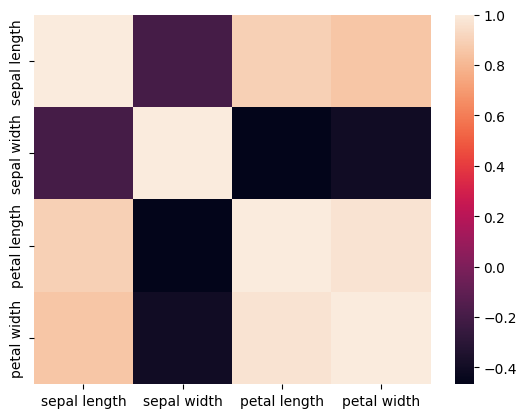

In [5]:
# dataloading

df = pd.read_csv('Dataset/iris_synthetic_data.csv')
# # df.sample(5)
plot = df[['sepal length','sepal width','petal length','petal width']].corr()
sns.heatmap(plot)

In [3]:
df.sample(2)
# groups = df.groupby('Hall Code')
# groups.groups

# df.iloc[[3, 15, 21, 44, 60, 89, 92, 94, 102, 112, 114, 120, 130],[-5,-1]]
c,d,e=0,0,0
for i in df['label']:
    if i=='Iris-setosa':
        c+=1
    elif i=='Iris-virginica':
        d+=1
    else:
        e+=1
s= c+d+e
c/s*100,d/s*100,e/s*100

     

(33.33333333333333, 33.33333333333333, 33.33333333333333)

In [4]:
# dataset with real world physics generalization features

# df = df[['Voltage (V)','Current (A)','Temperature (°C)','Motor Speed (RPM)','Estimated SOC (%)','Ground Truth SOC (%)','Fault Label']]
df['Fault Label'].unique()

KeyError: 'Fault Label'

In [ ]:
# data spliting

X = df.iloc[:,:-1]
Y = df.iloc[:,-1]
X,Y

In [ ]:
# train test splitting
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.25,random_state=56)
x_train.shape ,x_test.shape,y_train.shape,y_test.shape

In [ ]:
# feature scaling and class labeling
scaler = StandardScaler()
encoder = LabelEncoder() 

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)       # to prevent data leakage using training data's mean and deviation in test dataset

y_train = encoder.fit_transform(y_train)
y_test = encoder.fit_transform(y_test)

x_train[:2] , x_test[:2] , y_train[:2] , y_test[:2]

    Model_implementaion

In [ ]:
# onlyscratch
class param_:
    def __init__(self,n_features,n_class):
        np.random.seed(16)

        self.wh1 = np.random.randn(n_features,n_features-1)* np.sqrt(2/n_features).astype('float32')
        self.wh2 = np.random.randn(n_features-1,n_features-2)*np.sqrt(2/(n_features-1)).astype('float32')
        self.wOut = np.random.randn(n_features-2,n_class)*np.sqrt(2/(n_features-2)).astype('float32')
        # self.wOut = np.random.rand()
        self.bh1= np.random.randn((n_features-1))*np.sqrt(2/(n_features-1)).astype('float32'),
        self.bh2= np.random.randn((n_features-2))*np.sqrt(2/(n_features-2)).astype('float32'),
        self.bOut= np.random.randn((n_class))*np.sqrt(2/(n_class)).astype('float32')

class multiclassifier(param_):
    def __init__(self,features,labels, l_r= 1e-2):
        super().__init__(features.shape[1],3)
        self.labels=labels
        self.features=features
        self.l_r = l_r

        # print(self.n1.wInp,"\n",self.n1.wh1,"\n",self.n1.wh2)

    def softmax(self,x):
        z= np.exp(x-np.max(x,axis=1,keepdims= True))       # or exp(x)/sum(exp(x),axis=1)
        return z/np.sum(z,axis=1,keepdims=True)
        # print((np.exp(-x)[:,0]/z).shape)

    def forwardProp(self):
        # layer 1 logits
        y1 = self.features@self.wh1 + self.bh1
        y1 = np.maximum(0,y1)  # ReLU activation
        
        y2 = y1@self.wh2 + self.bh2
        y2 = np.maximum(0,y2)  # ReLU activation
    
        y3 = y2@self.wOut + self.bOut
        y3 = self.softmax(y3)
        return y3
    
    
    def backwardProp(self):
        # loss CrossEntropyLoss
        z = self.forwardProp()[np.arange(self.labels.shape[0]),self.labels] + 1e-11
        loss = np.mean(-1*np.log(z),keepdims=True) # total loss from every parameter
        return loss



obj = multiclassifier(x_train,y_train)
x = obj.backwardProp()
x

In [ ]:
[[0.30538566, 0.27378583, 0.42082851],
        [0.30538566, 0.27378583, 0.42082851],
        [0.30538566, 0.27378583, 0.42082851],
        ...,
        [0.30538566, 0.27378583, 0.42082851],
        [0.30538566, 0.27378583, 0.42082851],
        [0.30538566, 0.27378583, 0.42082851]], shape=(1775, 3)),
[[11.45002229, 11.55925156, 11.12937231],
        [10.25593878, 10.36516805,  9.9352888 ],
        [ 2.10330751,  2.21253678,  1.78265753],
        ...,
        [ 2.1273758 ,  2.23660506,  1.80672582],
        [ 5.9764593 ,  6.08568857,  5.65580932],
        [ 7.93580994,  8.0450392 ,  7.61515995]], shape=(1775, 3)))

In [ ]:
# import os
# print(os.getcwd())
np.sqrt(1/3)

In [ ]:
# print(os.listdir())